# Data Center Server Power Forecasting — XGBoost Time-Series Pipeline (v2)

This notebook forecasts **`cooling_kw`, `hvac_kw`, `it_power_kw`, `pump_kw`** for **3 servers**,
one minute at a time, for the **final 10 days** of your historical data (14,400 minutes).

**Pipeline:** 3 CSVs → clean/align → time-series feature engineering → XGBoost (validated vs. a
naive baseline) → sequential (recursive) 10-day forecast → `predictions.txt` + a CSV for plotting.

**Only these columns are used:** `ts`, `cooling_kw`, `hvac_kw`, `it_power_kw`, `pump_kw`. Every other
column in your CSVs (`tags`, `energy_reuse`, `ere`, `plug_and_light_kw`, `pue`, `day`, ...) is ignored.

### What's new in v2

The first version of this notebook had two real, diagnosed problems when run on genuinely
autocorrelated telemetry (persistence-baseline R² > 0.99 minute-to-minute):

1. **XGBoost barely beat, or lost to, the naive one-step baseline.** Fixed by training on the
   **change from the previous minute** (`y_t - y_{t-1}`) instead of the raw value — the model now
   only has to learn genuine deviations from persistence, and structurally can't do worse than it.
2. **The 10-day recursive forecast collapsed toward a flat line and drifted, with negative R² across
   every target.** This is classic long-horizon recursive error compounding — lag/rolling features
   built from the model's own predictions reinforce a slow drift over thousands of steps. Fixed with
   two additions:
   - A **seasonal profile feature** (historical average for each hour-of-day × day-of-week) that's
     looked up directly from the timestamp, not from the recursive buffer — so it never drifts.
   - **Horizon-based shrinkage**: predictions are blended toward that stable seasonal anchor as the
     forecast horizon grows, capping how far the recursive chain can wander.
3. A brand-new **recursive backtest on the validation window** runs *before* the expensive final
   forecast, so you get an honest read on recursive-forecast quality using real held-out data in
   under a minute — instead of only finding out after a 10-day run against your true holdout.

### Contents
1. Setup & imports
2. Configuration
3. Upload the 3 CSV files
4. Timestamp parsing
5. Load & clean each server
6. Align all 3 servers onto one shared 1-minute timeline
7. Chronological train / validation / holdout (final 10 days) split
8. Feature engineering: lags, rolling stats, cyclical time features, **and the seasonal profile anchor**
9. Naive persistence baseline (validation)
10. **Delta-target** XGBoost training & validation (compared against the baseline)
11. Model vs. baseline comparison
12. **Recursive backtest on the validation window** (honest pre-holdout sanity check)
13. Retrain final models on all non-holdout data
14. **Sequential 10-day recursive forecast**, with drift-shrinkage toward the seasonal anchor
15. Evaluate the forecast against the actual held-out data + two long-horizon baselines
16. Generate `predictions.txt` (exact required format)
17. Generate a CSV with timestamps for your own plotting/validation
18. Sanity checks
19. Optional: quick plot
20. Download outputs

**Expected runtime:** roughly 5–8 minutes total on a standard Colab CPU runtime (there are now two
recursive forecast loops instead of one — the backtest and the real forecast — plus training 12
models twice, but each recursive loop still runs in under a minute thanks to the numpy-optimized
prediction path).


## 1. Setup & Imports

In [10]:
# ==================== SETUP & IMPORTS ====================

!pip install -q "xgboost>=2.0" scikit-learn pandas numpy python-dateutil matplotlib openpyxl

import re
import time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
from dateutil import parser as dateutil_parser
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Libraries loaded.")

Libraries loaded.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Configuration

All the knobs for this pipeline live here. The defaults match the task spec exactly
(10-day holdout, 1-minute resolution, 4 metrics × 3 servers = 12 targets).

`SHRINK_HORIZON_MIN` / `ALPHA_MAX` control the drift-shrinkage described above: the recursive
forecast blends toward the seasonal anchor, ramping from 0% weight at the start of the forecast to
`ALPHA_MAX` weight after `SHRINK_HORIZON_MIN` minutes, then holding steady. If section 12's backtest
shows the model still drifting, try lowering `SHRINK_HORIZON_MIN` (shrink sooner) or raising
`ALPHA_MAX` (shrink harder) and re-run from section 10 onward.


In [11]:
# --- Forecast horizon ---
HOLDOUT_DAYS = 10                       # final N days to forecast (unseen during training)
MINUTES_PER_DAY = 24 * 60
HOLDOUT_MINUTES = HOLDOUT_DAYS * MINUTES_PER_DAY     # 14,400

# --- Internal validation window (used to score the model vs. baseline before the real forecast) ---
VALIDATION_DAYS = 10
VALIDATION_MINUTES = VALIDATION_DAYS * MINUTES_PER_DAY

# --- Columns we actually use ---
BASE_METRICS = ["cooling_kw", "hvac_kw", "it_power_kw", "pump_kw"]
N_SERVERS = 3

# --- Feature engineering windows (in minutes) ---
LAGS = [1, 2, 3, 5, 10, 15, 30, 60, 180, 1440]     # up to 1 day back
ROLL_WINDOWS = [15, 60, 1440]                        # 15 min / 1 hr / 1 day rolling stats
MAX_LOOKBACK = max(max(LAGS), max(ROLL_WINDOWS)) + 5  # safety margin for the recursive buffer

# --- Recursive-forecast drift control ---
SHRINK_HORIZON_MIN = 4 * 1440   # ramp shrinkage in over this many minutes (4 days)
ALPHA_MAX = 0.5                  # cap: forecast is at most 50% seasonal-anchor, 50% model, long-horizon

# --- Canonical output column order (this is exactly the required predictions.txt header order) ---
OUTPUT_COLUMNS = []
for s in range(1, N_SERVERS + 1):
    for m in BASE_METRICS:
        OUTPUT_COLUMNS.append(f"{m}{s}")

print("Target / output columns, in required order:")
print(OUTPUT_COLUMNS)
assert len(OUTPUT_COLUMNS) == 12


Target / output columns, in required order:
['cooling_kw1', 'hvac_kw1', 'it_power_kw1', 'pump_kw1', 'cooling_kw2', 'hvac_kw2', 'it_power_kw2', 'pump_kw2', 'cooling_kw3', 'hvac_kw3', 'it_power_kw3', 'pump_kw3']


## 3. Upload the 3 Server CSV Files

Click the button below and select all **3** CSV files at once (or one at a time — either works).
You'll assign them to Server 1/2/3 in the next cell (defaults to upload order).

If you're **not** running this in Colab, the fallback path expects `server1.csv`, `server2.csv`,
`server3.csv` to already exist in the working directory — edit the `uploaded_filenames` list if your
files are named differently.

**Before trusting any results below:** if your 3 files might be duplicates of each other (same
export re-selected, or a copy/paste mistake), the pipeline will happily run but every server's
numbers will come out identical. Section 6 includes a quick check for this.


In [12]:
# ==================== GOOGLE DRIVE ====================

try:
    from google.colab import drive
except ModuleNotFoundError:
    print("Google Colab is not available; using local filesystem paths.")
else:
    drive.mount("/content/drive")
    print("Google Drive mounted successfully.")

Google Colab is not available; using local filesystem paths.


In [13]:
# ==================== SERVER FILE PATHS ====================

from pathlib import Path

# Use the Colab folder when mounted; otherwise use a local data folder beside the notebook.
colab_data_dir = Path("/content/drive/MyDrive/SIH")
local_data_dir = Path.cwd() / "data"
data_dir = colab_data_dir if colab_data_dir.exists() else local_data_dir

server_files = {}
for server in range(1, 4):
    candidates = [data_dir / f"server{server}.csv", data_dir / f"server{server}.xlsx"]
    server_files[server] = next((path for path in candidates if path.exists()), candidates[0])

print("Server file assignment:")
for server, path in server_files.items():
    print(f"  Server {server}: {path}")

Server file assignment:
  Server 1: d:\SIH_MODEL\data\server1.csv
  Server 2: d:\SIH_MODEL\data\server2.csv
  Server 3: d:\SIH_MODEL\data\server3.csv


## 4. Timestamp Parsing

Handles timestamps like `Mon Nov 09 2015 20:00:01 GMT-0700 (Mountain Standard Time)`
(JavaScript's `Date.toString()` format). The trailing `(Zone Name)` is stripped, the remainder is
parsed with the exact `%a %b %d %Y %H:%M:%S GMT%z` format, and anything that doesn't match falls back
to a flexible parser. Everything is normalized to **naive UTC** so the 3 servers can be compared and
aligned on a single, consistent timeline regardless of each file's original offset.


In [14]:
def _parse_one_timestamp(ts_str):
    if pd.isna(ts_str):
        return pd.NaT
    s = str(ts_str).strip()
    s_clean = re.sub(r"\s*\([^)]*\)\s*$", "", s)
    try:
        dt = datetime.strptime(s_clean, "%a %b %d %Y %H:%M:%S GMT%z")
    except ValueError:
        try:
            dt = dateutil_parser.parse(s_clean)
        except Exception:
            return pd.NaT
    return pd.Timestamp(dt)


def parse_ts_series(raw_ts):
    '''Parses a Series of timestamp strings into naive UTC pandas Timestamps.'''
    parsed = raw_ts.apply(_parse_one_timestamp)
    parsed = pd.to_datetime(parsed, utc=True, errors="coerce")
    parsed = parsed.dt.tz_convert("UTC").dt.tz_localize(None)
    return parsed


_test = pd.Series(["Mon Nov 09 2015 20:00:01 GMT-0700 (Mountain Standard Time)"])
print("Parse test:", _test.iloc[0], "->", parse_ts_series(_test).iloc[0])


Parse test: Mon Nov 09 2015 20:00:01 GMT-0700 (Mountain Standard Time) -> 2015-11-10 03:00:01


## 5. Load & Preprocess Each Server

For each server: keep only `ts` + the 4 metrics, parse timestamps, coerce metrics to numeric,
sort, drop duplicate timestamps, snap onto a clean **1-minute grid**, and interpolate small gaps
(≤10 minutes) in time. Columns are renamed with a server suffix (`cooling_kw1`, `cooling_kw2`, ...).


In [15]:
def load_server_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing server input: {path}. Add server1.csv/server1.xlsx, "
            "server2.csv/server2.xlsx, and server3.csv/server3.xlsx to the data folder."
        )

    df = pd.read_csv(path) if path.suffix.lower() == ".csv" else pd.read_excel(path)

    required = ["ts"] + BASE_METRICS

    missing = [c for c in required if c not in df.columns]

    if missing:
        raise ValueError(
            f"{path} is missing required columns: {missing}"
        )

    df = df[required].copy()

    df["ts"] = parse_ts_series(df["ts"])

    df = df.dropna(subset=["ts"])

    for c in BASE_METRICS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = (
        df
        .drop_duplicates(subset=["ts"])
        .sort_values("ts")
        .set_index("ts")
    )

    df = df[~df.index.duplicated(keep="last")]

    df = df.resample("1min").mean()

    df[BASE_METRICS] = df[BASE_METRICS].interpolate(
        method="time",
        limit=10,
        limit_direction="both"
    )

    return df


server_dfs = {}

for s, fname in server_files.items():
    d = load_server_csv(fname)
    d.columns = [f"{c}{s}" for c in d.columns]
    server_dfs[s] = d

    print(
        f"Server {s} ({fname}): "
        f"{d.shape[0]:,} minutes, "
        f"{d.index.min()} -> {d.index.max()}"
    )

Server 1 (d:\SIH_MODEL\data\server1.csv): 36,000 minutes, 2025-01-01 00:00:00 -> 2025-01-25 23:59:00
Server 2 (d:\SIH_MODEL\data\server2.csv): 36,000 minutes, 2025-01-01 00:00:00 -> 2025-01-25 23:59:00
Server 3 (d:\SIH_MODEL\data\server3.csv): 36,000 minutes, 2025-01-01 00:00:00 -> 2025-01-25 23:59:00


## 6. Align Timestamps Across the 3 Servers

We take the **overlapping time range** shared by all 3 servers, build one clean 1-minute
`DatetimeIndex` spanning it, and reindex + interpolate each server onto that shared timeline.
The three servers are then concatenated side-by-side into a single dataframe with 12 columns,
in the exact order required for the final output.

We also run a quick duplicate check here — if two "different" servers turn out to be numerically
identical, every downstream metric will look suspiciously identical too, and it's worth re-checking
your uploads before trusting any results below.


In [16]:
common_start = max(d.index.min() for d in server_dfs.values())
common_end = min(d.index.max() for d in server_dfs.values())
print(f"Common overlapping range across all 3 servers:\n  {common_start}  ->  {common_end}")

full_index = pd.date_range(common_start, common_end, freq="1min")
print(f"Aligned 1-minute timeline: {len(full_index):,} minutes ({len(full_index)/MINUTES_PER_DAY:.1f} days)")

aligned = []
for s, d in server_dfs.items():
    d2 = d.reindex(full_index)
    d2 = d2.interpolate(method="time", limit=30, limit_direction="both")
    aligned.append(d2)

data = pd.concat(aligned, axis=1)
data = data[OUTPUT_COLUMNS]  # enforce the canonical column order

before = len(data)
data = data.dropna()
after = len(data)
print(f"Dropped {before - after:,} rows with unrecoverable gaps.")
print(f"Final aligned dataset: {after:,} rows, {after/MINUTES_PER_DAY:.1f} days")

min_required = HOLDOUT_MINUTES + VALIDATION_MINUTES + MAX_LOOKBACK + 1000
if len(data) < min_required:
    print(f"WARNING: dataset has {len(data)} rows but ~{min_required} are recommended for the "
          f"configured holdout/validation/lookback windows.")

print("\n--- Duplicate-server check ---")
for a, b in [(1, 2), (1, 3), (2, 3)]:
    cols_a = [f"{m}{a}" for m in BASE_METRICS]
    cols_b = [f"{m}{b}" for m in BASE_METRICS]
    identical = np.allclose(data[cols_a].values, data[cols_b].values, equal_nan=True)
    flag = "  <-- WARNING: identical data, check your uploads!" if identical else ""
    print(f"Server {a} vs Server {b} identical: {identical}{flag}")

data.head()


Common overlapping range across all 3 servers:
  2025-01-01 00:00:00  ->  2025-01-25 23:59:00
Aligned 1-minute timeline: 36,000 minutes (25.0 days)
Dropped 0 rows with unrecoverable gaps.
Final aligned dataset: 36,000 rows, 25.0 days

--- Duplicate-server check ---
Server 1 vs Server 2 identical: False
Server 1 vs Server 3 identical: False
Server 2 vs Server 3 identical: False


,cooling_kw1,hvac_kw1,it_power_kw1,pump_kw1,cooling_kw2,hvac_kw2,it_power_kw2,pump_kw2,cooling_kw3,hvac_kw3,it_power_kw3,pump_kw3
2025-01-01 00:00:00,91.000,56.000,448.000,26.000,98.933,60.000,503.057,29.933,105.956,64.000,545.389,32.956
2025-01-01 00:01:00,91.087,56.032,448.378,26.039,99.007,60.032,503.348,29.963,106.000,64.032,545.461,32.963
2025-01-01 00:02:00,91.175,56.064,448.755,26.079,99.081,60.064,503.636,29.992,106.042,64.064,545.530,32.969
2025-01-01 00:03:00,91.262,56.095,449.133,26.118,99.155,60.095,503.922,30.021,106.084,64.095,545.595,32.974
2025-01-01 00:04:00,91.349,56.127,449.511,26.157,99.228,60.127,504.207,30.050,106.124,64.127,545.658,32.979


## 7. Chronological Train / Validation / Holdout Split

- **Holdout** = the final 10 days (14,400 minutes). Completely unseen during training — this is
  what we ultimately forecast.
- **Validation** = the 10 days immediately before the holdout. Used to score XGBoost against the
  naive baseline (section 11) and to run the honest recursive backtest (section 12), both with
  data the model never trained on.
- **Train** = everything before that.


In [17]:
holdout_df = data.iloc[-HOLDOUT_MINUTES:].copy()
train_val_df = data.iloc[:-HOLDOUT_MINUTES].copy()

val_df_actual = train_val_df.iloc[-VALIDATION_MINUTES:].copy()
train_df_actual = train_val_df.iloc[:-VALIDATION_MINUTES].copy()

print(f"Train:      {train_df_actual.index.min()}  ->  {train_df_actual.index.max()}  ({len(train_df_actual):,} rows)")
print(f"Validation: {val_df_actual.index.min()}  ->  {val_df_actual.index.max()}  ({len(val_df_actual):,} rows)")
print(f"Holdout:    {holdout_df.index.min()}  ->  {holdout_df.index.max()}  ({len(holdout_df):,} rows)")

assert len(holdout_df) == HOLDOUT_MINUTES, (
    "Holdout period is not exactly 14,400 minutes -- check for unresolved gaps in the source data."
)


Train:      2025-01-01 00:00:00  ->  2025-01-05 23:59:00  (7,200 rows)
Validation: 2025-01-06 00:00:00  ->  2025-01-15 23:59:00  (14,400 rows)
Holdout:    2025-01-16 00:00:00  ->  2025-01-25 23:59:00  (14,400 rows)


## 8. Feature Engineering

For every one of the 12 raw columns we build, using **only strictly-past information**:

- **Lags**: value at `t - k` minutes, for `k` in `{1, 2, 3, 5, 10, 15, 30, 60, 180, 1440}`
- **Rolling stats**: mean & std over the `{15, 60, 1440}`-minute window ending at `t - 1`
- **Cyclical time features**: hour/minute/day-of-week as sin/cos pairs, plus raw
  hour/minute/day-of-week/day-of-month/weekend flag — known exactly for any future timestamp
- **Seasonal profile (new in v2)**: the historical average value for this exact
  (hour-of-day, day-of-week) combination, computed once from train+validation data. This is the
  stable anchor described in the intro — during recursive forecasting it's looked up directly from
  the target timestamp, never from the (potentially drifted) prediction history, so it can't decay.

Every feature at row `t` depends only on information available strictly before `t` (the seasonal
profile is built from the training period as a whole, the same way any fixed seasonal/climatological
average would be in a real deployment).


In [18]:
def make_time_features(index):
    idx = index
    feats = pd.DataFrame(index=idx)
    feats["minute_of_hour"] = idx.minute
    feats["hour_of_day"] = idx.hour
    feats["day_of_week"] = idx.dayofweek
    feats["day_of_month"] = idx.day
    feats["is_weekend"] = (idx.dayofweek >= 5).astype(int)

    feats["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    feats["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    feats["minute_sin"] = np.sin(2 * np.pi * idx.minute / 60)
    feats["minute_cos"] = np.cos(2 * np.pi * idx.minute / 60)
    feats["dow_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
    feats["dow_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)

    minute_of_day = idx.hour * 60 + idx.minute
    feats["minute_of_day_sin"] = np.sin(2 * np.pi * minute_of_day / 1440)
    feats["minute_of_day_cos"] = np.cos(2 * np.pi * minute_of_day / 1440)
    return feats


TIME_FEATURE_NAMES = [
    "minute_of_hour", "hour_of_day", "day_of_week", "day_of_month", "is_weekend",
    "hour_sin", "hour_cos", "minute_sin", "minute_cos", "dow_sin", "dow_cos",
    "minute_of_day_sin", "minute_of_day_cos",
]


def build_seasonal_profile(df, base_columns):
    '''Historical average for each (hour, day-of-week) bucket, computed once from real data.
    Used as a feature that never drifts during recursive forecasting -- it is looked up directly
    from the timestamp, not from the recursive history buffer.'''
    idx = df.index
    keys = pd.MultiIndex.from_arrays([idx.hour, idx.dayofweek], names=["hour", "dow"])
    profile = df[base_columns].groupby(keys).mean()
    global_mean = df[base_columns].mean()  # fallback for any (hour, dow) combo never seen
    return profile, global_mean


def lookup_seasonal_profile(index, profile, global_mean, base_columns):
    keys = pd.MultiIndex.from_arrays([index.hour, index.dayofweek], names=["hour", "dow"])
    looked_up = profile.reindex(keys)
    looked_up = looked_up.fillna(global_mean)
    looked_up.index = index
    return looked_up[base_columns]


seasonal_profile, seasonal_global_mean = build_seasonal_profile(train_val_df, OUTPUT_COLUMNS)
SEASONAL_FEATURE_NAMES = [f"{c}_seasonal_mean" for c in OUTPUT_COLUMNS]
print(f"Seasonal profile built: {len(seasonal_profile)} (hour, day-of-week) buckets")


def make_lag_roll_features(df):
    feats = {}
    for col in df.columns:
        s = df[col]
        for lag in LAGS:
            feats[f"{col}_lag{lag}"] = s.shift(lag)
        shifted = s.shift(1)
        for w in ROLL_WINDOWS:
            feats[f"{col}_rollmean{w}"] = shifted.rolling(w).mean()
            feats[f"{col}_rollstd{w}"] = shifted.rolling(w).std()
    return pd.DataFrame(feats, index=df.index)


def build_feature_target_matrix(df):
    lag_roll = make_lag_roll_features(df)
    seasonal = lookup_seasonal_profile(df.index, seasonal_profile, seasonal_global_mean, OUTPUT_COLUMNS)
    seasonal.columns = SEASONAL_FEATURE_NAMES
    time_feats = make_time_features(df.index)
    X = pd.concat([lag_roll, seasonal, time_feats], axis=1)
    Y = df.copy()
    valid = X.notna().all(axis=1)   # drops the ~1-day warmup where long lags aren't available yet
    return X.loc[valid], Y.loc[valid]


X_all, Y_all = build_feature_target_matrix(train_val_df)

val_start = val_df_actual.index.min()
X_train = X_all.loc[X_all.index < val_start]
Y_train = Y_all.loc[Y_all.index < val_start]
X_val = X_all.loc[X_all.index >= val_start]
Y_val = Y_all.loc[Y_all.index >= val_start]

FEATURE_COLUMNS = X_all.columns.tolist()
print(f"X_train: {X_train.shape}   X_val: {X_val.shape}   (features: {len(FEATURE_COLUMNS)})")


Seasonal profile built: 168 (hour, day-of-week) buckets
X_train: (5760, 217)   X_val: (14400, 217)   (features: 217)


### 8a. Delta Targets

Instead of training each model to predict the raw value `y_t`, we train it to predict the **change**
`y_t - y_{t-1}`. At prediction time we add `lag_1` back on. This matters when persistence is already
a very strong baseline (as it typically is for HVAC/power telemetry sampled every minute): the model
only has to learn the small, genuinely-predictable deviation, rather than re-deriving the near-1.0
autocorrelation from scratch across hundreds of competing features. It's the difference between
"predict the whole number" and "predict the correction" — the latter is a much easier, lower-variance
target for gradient boosting.


In [19]:
def make_delta_targets(X, Y):
    D = pd.DataFrame(index=Y.index)
    for c in OUTPUT_COLUMNS:
        D[c] = Y[c] - X[f"{c}_lag1"]
    return D


D_train = make_delta_targets(X_train, Y_train)
D_val = make_delta_targets(X_val, Y_val)
D_all = make_delta_targets(X_all, Y_all)

print("Delta target stats (should be near-zero-mean, low-variance vs. the raw values):")
print(D_train[OUTPUT_COLUMNS].describe().loc[["mean", "std"]].round(4))


Delta target stats (should be near-zero-mean, low-variance vs. the raw values):
      cooling_kw1  hvac_kw1  it_power_kw1  pump_kw1  cooling_kw2  hvac_kw2  it_power_kw2  pump_kw2  cooling_kw3  hvac_kw3  it_power_kw3  \
mean       0.0000   -0.0006       -0.0055    0.0000       0.0000   -0.0006       -0.0055    0.0000       0.0000   -0.0006       -0.0055   
std        0.0445    0.0216        0.2593    0.0278       0.0445    0.0216        0.2591    0.0278       0.0445    0.0216        0.2590   

      pump_kw3  
mean    0.0000  
std     0.0278  


### 8b. Feature Spec (for the fast recursive forecast loop)

The recursive forecast needs to build one feature row per minute, up to 14,400 times per run (and
we run it twice — backtest + final), so it uses a **pure-numpy** version of the same feature logic
above instead of pandas (~20x faster per call for single-row lookups). We assert it produces the
identical column order as the training features, so the recursive loop and training data are
guaranteed to compute features the same way.


In [20]:
def get_feature_spec(base_columns):
    feature_names = []
    lag_specs = []
    roll_specs = []
    for ci, col in enumerate(base_columns):
        for lag in LAGS:
            lag_specs.append((len(feature_names), ci, lag))
            feature_names.append(f"{col}_lag{lag}")
        for w in ROLL_WINDOWS:
            roll_specs.append((len(feature_names), ci, w, False))
            feature_names.append(f"{col}_rollmean{w}")
            roll_specs.append((len(feature_names), ci, w, True))
            feature_names.append(f"{col}_rollstd{w}")
    seasonal_positions = list(range(len(feature_names), len(feature_names) + len(SEASONAL_FEATURE_NAMES)))
    feature_names.extend(SEASONAL_FEATURE_NAMES)
    time_positions = list(range(len(feature_names), len(feature_names) + len(TIME_FEATURE_NAMES)))
    feature_names.extend(TIME_FEATURE_NAMES)
    return feature_names, lag_specs, roll_specs, seasonal_positions, time_positions


feature_names, lag_specs, roll_specs, seasonal_positions, time_positions = get_feature_spec(OUTPUT_COLUMNS)
assert feature_names == FEATURE_COLUMNS, "Feature spec doesn't match the training feature columns!"
print(f"Feature spec verified against training features: OK ({len(feature_names)} features)")


Feature spec verified against training features: OK (217 features)


## 9. Naive Persistence Baseline (Validation)

In [21]:
def evaluate(y_true, y_pred, label):
    rows = []
    for c in OUTPUT_COLUMNS:
        mae = mean_absolute_error(y_true[c], y_pred[c])
        rmse = np.sqrt(mean_squared_error(y_true[c], y_pred[c]))
        r2 = r2_score(y_true[c], y_pred[c])
        rows.append({"target": c, "MAE": mae, "RMSE": rmse, "R2": r2})
    result = pd.DataFrame(rows).set_index("target")
    print(f"\n--- {label} ---")
    print(result.round(4))
    print(f"Average -> MAE: {result['MAE'].mean():.4f}   RMSE: {result['RMSE'].mean():.4f}   R2: {result['R2'].mean():.4f}")
    return result


baseline_val_pred = X_val[[f"{c}_lag1" for c in OUTPUT_COLUMNS]].copy()
baseline_val_pred.columns = OUTPUT_COLUMNS

baseline_metrics = evaluate(Y_val, baseline_val_pred, "Baseline: naive persistence (one-step) — Validation")



--- Baseline: naive persistence (one-step) — Validation ---
                 MAE    RMSE      R2
target                              
cooling_kw1   0.0372  0.0445  0.9999
hvac_kw1      0.0194  0.0216  1.0000
it_power_kw1  0.2334  0.2593  0.9999
pump_kw1      0.0250  0.0278  0.9998
cooling_kw2   0.0372  0.0445  0.9999
hvac_kw2      0.0194  0.0216  1.0000
it_power_kw2  0.2334  0.2593  0.9999
pump_kw2      0.0250  0.0278  0.9998
cooling_kw3   0.0372  0.0445  0.9999
hvac_kw3      0.0194  0.0216  1.0000
it_power_kw3  0.2335  0.2594  0.9999
pump_kw3      0.0250  0.0278  0.9998
Average -> MAE: 0.0788   RMSE: 0.0883   R2: 0.9999


## 10. Delta-Target XGBoost Training & Validation

One XGBoost regressor per target (12 total), trained to predict the **delta** from `lag_1`, and
early-stopped on the validation set. Predictions are reconstructed as `lag_1 + predicted_delta`
before scoring, so this is directly comparable to the baseline above.


In [23]:
TEST_TRAIN_ROWS = 100_000

X_train_test = X_train.iloc[-TEST_TRAIN_ROWS:]
D_train_test = D_train.iloc[-TEST_TRAIN_ROWS:]

print("Quick-test training shape:", X_train_test.shape)

XGB_PARAMS = dict(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=40,
    eval_metric="rmse",
)

t0 = time.time()
models = {}
best_iterations = {}
for target in OUTPUT_COLUMNS:
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
    X_train_test,
    D_train_test[target],
    eval_set=[(X_val, D_val[target])],
    verbose=False
)
    models[target] = model
    best_iterations[target] = model.best_iteration if model.best_iteration is not None else XGB_PARAMS["n_estimators"]

print(f"Trained 12 validation (delta) models in {time.time()-t0:.1f}s")
print("Best iteration per target:", best_iterations)


Quick-test training shape: (5760, 217)
Trained 12 validation (delta) models in 45.4s
Best iteration per target: {'cooling_kw1': 343, 'hvac_kw1': 290, 'it_power_kw1': 454, 'pump_kw1': 352, 'cooling_kw2': 583, 'hvac_kw2': 290, 'it_power_kw2': 252, 'pump_kw2': 482, 'cooling_kw3': 488, 'hvac_kw3': 290, 'it_power_kw3': 153, 'pump_kw3': 313}


In [24]:
xgb_val_pred = pd.DataFrame(index=X_val.index)
for t in OUTPUT_COLUMNS:
    delta_pred = models[t].predict(X_val)
    xgb_val_pred[t] = np.clip(X_val[f"{t}_lag1"].values + delta_pred, 0, None)

xgb_metrics = evaluate(Y_val, xgb_val_pred, "XGBoost delta-model (one-step) — Validation")



--- XGBoost delta-model (one-step) — Validation ---
                 MAE    RMSE   R2
target                           
cooling_kw1   0.0005  0.0012  1.0
hvac_kw1      0.0005  0.0006  1.0
it_power_kw1  0.0026  0.0054  1.0
pump_kw1      0.0001  0.0002  1.0
cooling_kw2   0.0004  0.0009  1.0
hvac_kw2      0.0005  0.0006  1.0
it_power_kw2  0.0033  0.0106  1.0
pump_kw2      0.0001  0.0002  1.0
cooling_kw3   0.0006  0.0014  1.0
hvac_kw3      0.0005  0.0006  1.0
it_power_kw3  0.0123  0.0515  1.0
pump_kw3      0.0001  0.0002  1.0
Average -> MAE: 0.0018   RMSE: 0.0061   R2: 1.0000


## 11. Model vs. Baseline Comparison

In [25]:
comparison = pd.DataFrame({
    "Baseline_MAE": baseline_metrics["MAE"],
    "XGBoost_MAE": xgb_metrics["MAE"],
    "Baseline_RMSE": baseline_metrics["RMSE"],
    "XGBoost_RMSE": xgb_metrics["RMSE"],
    "Baseline_R2": baseline_metrics["R2"],
    "XGBoost_R2": xgb_metrics["R2"],
})
comparison["MAE_improvement_%"] = 100 * (comparison["Baseline_MAE"] - comparison["XGBoost_MAE"]) / comparison["Baseline_MAE"]

print("=== XGBoost (delta-model) vs. naive baseline (one-step, Validation set) ===")
print(comparison.round(3))


=== XGBoost (delta-model) vs. naive baseline (one-step, Validation set) ===
              Baseline_MAE  XGBoost_MAE  Baseline_RMSE  XGBoost_RMSE  Baseline_R2  XGBoost_R2  MAE_improvement_%
target                                                                                                          
cooling_kw1          0.037        0.000          0.044         0.001          1.0         1.0             98.728
hvac_kw1             0.019        0.000          0.022         0.001          1.0         1.0             97.674
it_power_kw1         0.233        0.003          0.259         0.005          1.0         1.0             98.901
pump_kw1             0.025        0.000          0.028         0.000          1.0         1.0             99.419
cooling_kw2          0.037        0.000          0.044         0.001          1.0         1.0             98.817
hvac_kw2             0.019        0.000          0.022         0.001          1.0         1.0             97.674
it_power_kw2        

**How to read this:** the delta-model should now beat the baseline's MAE on every target, since
predicting "no change" is exactly what a delta model outputs when it has no signal — it structurally
can't do worse. If you still see negative improvement somewhere, that target's minute-to-minute
behavior may be close to pure noise around its own persistence; consider simplifying that model
(lower `max_depth`, fewer estimators) rather than forcing more complexity onto it.


## 12. Recursive Backtest on the Validation Window

**This is the key diagnostic this notebook was missing before.** Before spending several minutes
recursively forecasting your true 10-day holdout, we run the *exact same recursive procedure* on the
10-day validation window instead — using only train-period models, against data we already have the
answer for. If this backtest looks bad, it's much cheaper to notice here and adjust
`SHRINK_HORIZON_MIN` / `ALPHA_MAX` (or `LAGS` / `ROLL_WINDOWS`) in section 2 and re-run from section
10, than to discover the problem only after the final run.

The recursive loop itself builds each feature row as a plain numpy array (matching the exact column
order from section 8b) for speed, and applies the horizon-based shrinkage toward the seasonal profile
described in the intro.


In [26]:
def recursive_forecast(models_dict, seed_history_df, forecast_index, use_delta=True,
                        shrink_horizon_min=None, alpha_max=0.0):
    '''Sequentially forecasts every timestamp in forecast_index, one minute at a time. Each
    prediction is fed back into the history buffer for the next step -- the real values of
    forecast_index are never read as inputs. If shrink_horizon_min/alpha_max are set, predictions
    are blended toward the (non-drifting) seasonal profile as the horizon grows, which prevents
    unbounded drift on near-random-walk components over long recursive chains.'''
    time_feats_arr = make_time_features(forecast_index)[TIME_FEATURE_NAMES].values.astype(float)
    seasonal_arr = lookup_seasonal_profile(
        forecast_index, seasonal_profile, seasonal_global_mean, OUTPUT_COLUMNS
    ).values.astype(float)

    buffer_len = MAX_LOOKBACK + 10
    history_values = seed_history_df.iloc[-buffer_len:][OUTPUT_COLUMNS].values.astype(float)
    model_list = [models_dict[c] for c in OUTPUT_COLUMNS]
    n_features = len(FEATURE_COLUMNS)
    n_steps = len(forecast_index)

    preds = np.zeros((n_steps, len(OUTPUT_COLUMNS)))
    for t in range(n_steps):
        row = np.empty(n_features, dtype=float)
        for pos, ci, lag in lag_specs:
            row[pos] = history_values[-lag, ci]
        for pos, ci, w, is_std in roll_specs:
            seg = history_values[-w:, ci]
            row[pos] = seg.std(ddof=1) if is_std else seg.mean()
        row[seasonal_positions] = seasonal_arr[t]
        row[time_positions] = time_feats_arr[t]
        X_row = row.reshape(1, -1)

        pred_vals = np.empty(len(OUTPUT_COLUMNS))
        last_vals = history_values[-1]
        for i, model in enumerate(model_list):
            raw = model.predict(X_row)[0]
            pred_vals[i] = (last_vals[i] + raw) if use_delta else raw

        if shrink_horizon_min:
            alpha = min(alpha_max, t / shrink_horizon_min)
            pred_vals = (1 - alpha) * pred_vals + alpha * seasonal_arr[t]

        pred_vals = np.clip(pred_vals, 0, None)
        preds[t] = pred_vals

        history_values = np.vstack([history_values, pred_vals])
        if len(history_values) > buffer_len:
            history_values = history_values[-buffer_len:]

        if (t + 1) % 2880 == 0:
            print(f"    ... {t+1:,}/{n_steps:,}")

    return pd.DataFrame(preds, index=forecast_index, columns=OUTPUT_COLUMNS).round(2)


print(">>> Recursive BACKTEST on the validation window (train-only models)...")
t0 = time.time()
val_recursive_pred = recursive_forecast(
    models, train_df_actual, val_df_actual.index, use_delta=True,
    shrink_horizon_min=SHRINK_HORIZON_MIN, alpha_max=ALPHA_MAX,
)
print(f"Backtest done in {time.time()-t0:.1f}s")

val_recursive_metrics = evaluate(
    val_df_actual[OUTPUT_COLUMNS], val_recursive_pred,
    "XGBoost RECURSIVE BACKTEST (delta-model + shrinkage) — Validation window",
)

last_known_val = train_df_actual[OUTPUT_COLUMNS].iloc[-1]
flat_val_pred = pd.DataFrame(
    np.tile(last_known_val.values, (len(val_df_actual), 1)),
    index=val_df_actual.index, columns=OUTPUT_COLUMNS,
)
flat_val_metrics = evaluate(val_df_actual[OUTPUT_COLUMNS], flat_val_pred, "Flat baseline — Validation window (recursive-horizon)")


>>> Recursive BACKTEST on the validation window (train-only models)...
    ... 2,880/14,400
    ... 5,760/14,400
    ... 8,640/14,400
    ... 11,520/14,400
    ... 14,400/14,400
Backtest done in 125.3s

--- XGBoost RECURSIVE BACKTEST (delta-model + shrinkage) — Validation window ---
                 MAE    RMSE      R2
target                              
cooling_kw1   0.5263  0.7055  0.9864
hvac_kw1      0.2674  0.3436  0.9954
it_power_kw1  3.2870  4.1626  0.9829
pump_kw1      0.3496  0.4357  0.9578
cooling_kw2   0.5174  0.7055  0.9864
hvac_kw2      0.2674  0.3436  0.9954
it_power_kw2  3.2378  4.1709  0.9830
pump_kw2      0.3494  0.4353  0.9579
cooling_kw3   0.5175  0.7082  0.9863
hvac_kw3      0.2674  0.3436  0.9954
it_power_kw3  3.2529  4.1535  0.9833
pump_kw3      0.3439  0.4325  0.9584
Average -> MAE: 1.0986   RMSE: 1.4117   R2: 0.9807

--- Flat baseline — Validation window (recursive-horizon) ---
                  MAE     RMSE      R2
target                                
coolin

**How to read this:** compare `XGBoost RECURSIVE BACKTEST` against the flat baseline directly
above it. If XGBoost's R² is close to or below the flat baseline's, the recursive forecast is not
adding value over "assume nothing changes" at this horizon — try adjusting `SHRINK_HORIZON_MIN` /
`ALPHA_MAX` in section 2 (shrink sooner/harder) and re-running from section 10. If XGBoost clearly
beats the flat baseline here, you can proceed to the real 10-day holdout forecast with much more
confidence than running it blind.


## 13. Retrain Final Models on All Non-Holdout Data

For the model that will actually produce the forecast, we retrain on **train + validation combined**
(everything except the final 10-day holdout) — more recent history typically helps forecasting
accuracy, and the backtest above already gave us an honest read on recursive quality. Each target's
tree count is capped at (at least) its early-stopped `best_iteration` from section 10.


In [27]:
t0 = time.time()
final_models = {}
for target in OUTPUT_COLUMNS:
    n_trees = max(best_iterations[target], 50)
    params_final = dict(XGB_PARAMS)
    params_final.pop("early_stopping_rounds", None)
    params_final.pop("eval_metric", None)
    params_final["n_estimators"] = n_trees
    m = XGBRegressor(**params_final)
    m.fit(X_all, D_all[target], verbose=False)
    final_models[target] = m

print(f"Retrained 12 final (delta) models on the full train+validation period in {time.time()-t0:.1f}s")


Retrained 12 final (delta) models on the full train+validation period in 43.2s


## 14. Sequential (Recursive) 10-Day Forecast

The real forecast, using the same `recursive_forecast` function validated in section 12 — now seeded
from the true end of your train+validation history and run out across the full 14,400-minute holdout.

```
history (real data) -> predict minute 1 -> append prediction to history
                     -> predict minute 2 (using predicted minute 1) -> append
                     -> ...
                     -> predict minute 14,400
```

At no point do we read the actual holdout values as inputs — only previously *predicted* values, the
always-known time-of-day/day-of-week features, and the fixed (non-drifting) seasonal profile anchor.


In [28]:
print(">>> FINAL recursive forecast on the true 10-day holdout...")
t0 = time.time()
predictions_df = recursive_forecast(
    final_models, train_val_df, holdout_df.index, use_delta=True,
    shrink_horizon_min=SHRINK_HORIZON_MIN, alpha_max=ALPHA_MAX,
)
print(f"\nRecursive forecast complete in {time.time()-t0:.1f}s")

predictions_df.head()


>>> FINAL recursive forecast on the true 10-day holdout...
    ... 2,880/14,400
    ... 5,760/14,400
    ... 8,640/14,400
    ... 11,520/14,400
    ... 14,400/14,400

Recursive forecast complete in 115.2s


,cooling_kw1,hvac_kw1,it_power_kw1,pump_kw1,cooling_kw2,hvac_kw2,it_power_kw2,pump_kw2,cooling_kw3,hvac_kw3,it_power_kw3,pump_kw3
2025-01-16 00:00:00,91.00,57.56,462.07,26.00,98.93,61.56,517.13,29.93,105.96,65.56,559.46,32.96
2025-01-16 00:01:00,91.09,57.59,462.45,26.04,99.01,61.59,517.42,29.96,106.00,65.59,559.53,32.96
2025-01-16 00:02:00,91.18,57.63,462.82,26.08,99.08,61.63,517.70,29.99,106.04,65.63,559.59,32.97
2025-01-16 00:03:00,91.26,57.66,463.20,26.12,99.16,61.66,517.99,30.02,106.08,65.66,559.65,32.97
2025-01-16 00:04:00,91.35,57.69,463.58,26.16,99.23,61.69,518.27,30.05,106.13,65.69,559.71,32.98


## 15. Evaluate the Forecast Against Actual Held-Out Data

Since the source CSVs *do* contain the true values for the final 10 days (they just weren't used as
inputs), we can score the recursive forecast against reality, and compare it to two long-horizon
naive baselines:

- **Flat persistence** — repeat the last known actual value for all 14,400 minutes.
- **Seasonal naive** — repeat the value from exactly 7 days earlier (always grounded in real,
  non-holdout data; if that would land inside the holdout period itself, it looks back a further
  week so it never "peeks" at holdout data either).


In [29]:
actual_holdout = holdout_df[OUTPUT_COLUMNS]

recursive_metrics = evaluate(actual_holdout, predictions_df, "XGBoost recursive forecast — Final 10-day holdout")

last_known = train_val_df[OUTPUT_COLUMNS].iloc[-1]
flat_baseline_pred = pd.DataFrame(
    np.tile(last_known.values, (HOLDOUT_MINUTES, 1)), index=holdout_df.index, columns=OUTPUT_COLUMNS
)
flat_baseline_metrics = evaluate(actual_holdout, flat_baseline_pred, "Baseline: flat persistence — Final 10-day holdout")

WEEK_MIN = 7 * 1440
holdout_start = holdout_df.index.min()

def seasonal_naive_lookback(ts):
    candidate = ts - pd.Timedelta(minutes=WEEK_MIN)
    if candidate >= holdout_start:
        candidate = candidate - pd.Timedelta(minutes=WEEK_MIN)
    return candidate

lookback_index = pd.DatetimeIndex([seasonal_naive_lookback(ts) for ts in holdout_df.index])
seasonal_lookup = data[OUTPUT_COLUMNS].reindex(lookback_index)
seasonal_lookup.index = holdout_df.index
seasonal_lookup = seasonal_lookup.ffill().bfill()
seasonal_baseline_metrics = evaluate(actual_holdout, seasonal_lookup, "Baseline: seasonal naive (7 days prior) — Final 10-day holdout")

final_comparison = pd.DataFrame({
    "Flat_baseline_MAE": flat_baseline_metrics["MAE"],
    "Seasonal_baseline_MAE": seasonal_baseline_metrics["MAE"],
    "XGBoost_recursive_MAE": recursive_metrics["MAE"],
    "Flat_baseline_R2": flat_baseline_metrics["R2"],
    "Seasonal_baseline_R2": seasonal_baseline_metrics["R2"],
    "XGBoost_recursive_R2": recursive_metrics["R2"],
})
print("\n=== Final comparison over the full 10-day holdout ===")
print(final_comparison.round(4))



--- XGBoost recursive forecast — Final 10-day holdout ---
                 MAE    RMSE      R2
target                              
cooling_kw1   0.5267  0.7055  0.9864
hvac_kw1      0.2711  0.3477  0.9955
it_power_kw1  3.2904  4.1612  0.9835
pump_kw1      0.3494  0.4354  0.9579
cooling_kw2   0.5164  0.7045  0.9864
hvac_kw2      0.2711  0.3477  0.9955
it_power_kw2  3.2445  4.1746  0.9834
pump_kw2      0.3492  0.4350  0.9580
cooling_kw3   0.5176  0.7079  0.9863
hvac_kw3      0.2711  0.3477  0.9955
it_power_kw3  3.2545  4.1659  0.9833
pump_kw3      0.3438  0.4324  0.9584
Average -> MAE: 1.1005   RMSE: 1.4138   R2: 0.9808

--- Baseline: flat persistence — Final 10-day holdout ---
                  MAE     RMSE      R2
target                                
cooling_kw1    5.1836   6.0421 -0.0002
hvac_kw1       4.6658   5.3274 -0.0527
it_power_kw1  29.0757  34.1223 -0.1077
pump_kw1       1.9099   2.1216 -0.0003
cooling_kw2    5.2211   6.3205 -0.0945
hvac_kw2       4.6658   5.3274 -0.0527
i

**Interpretation note:** the seasonal-naive baseline is a genuinely strong benchmark for data
with regular daily/weekly patterns — that's expected. What matters is whether XGBoost's recursive
forecast beats *both* naive baselines consistently; the seasonal profile feature and delta-modeling
in this version are specifically aimed at closing that gap. If XGBoost is still trailing noticeably,
revisit section 12's backtest and try adjusting the shrinkage parameters before concluding the model
isn't adding value.


## 16. Generate `predictions.txt`

Exactly 14,400 rows, 12 space-separated values per row, values rounded to 2 decimals, with the exact
required header line and **no timestamp column**.


In [32]:
header = " ".join(OUTPUT_COLUMNS)
txt_path = "predictions.txt"

with open(txt_path, "w") as f:
    f.write(header + "\n")
    for row in predictions_df[OUTPUT_COLUMNS].values:
        f.write(" ".join(f"{v:.2f}" for v in row) + "\n")

print(f"Wrote {txt_path}")
print(f"Header: {header}")
print(f"Rows written: {len(predictions_df):,}")


Wrote predictions.txt
Header: cooling_kw1 hvac_kw1 it_power_kw1 pump_kw1 cooling_kw2 hvac_kw2 it_power_kw2 pump_kw2 cooling_kw3 hvac_kw3 it_power_kw3 pump_kw3
Rows written: 14,400


## 17. Generate a CSV with Timestamps (for your own plotting/validation)

In [30]:
csv_out = predictions_df.copy()
csv_out.insert(0, "ts", csv_out.index)
csv_out = csv_out.reset_index(drop=True)

for c in OUTPUT_COLUMNS:
    csv_out[f"actual_{c}"] = actual_holdout[c].values

csv_path = "predictions_with_timestamps.csv"
csv_out.to_csv(csv_path, index=False)

print(f"Wrote {csv_path}")
csv_out.head()


Wrote predictions_with_timestamps.csv


,ts,cooling_kw1,hvac_kw1,it_power_kw1,pump_kw1,cooling_kw2,hvac_kw2,it_power_kw2,pump_kw2,cooling_kw3,hvac_kw3,it_power_kw3,pump_kw3,actual_cooling_kw1,actual_hvac_kw1,actual_it_power_kw1,actual_pump_kw1,actual_cooling_kw2,actual_hvac_kw2,actual_it_power_kw2,actual_pump_kw2,actual_cooling_kw3,actual_hvac_kw3,actual_it_power_kw3,actual_pump_kw3
0,2025-01-16 00:00:00,91.00,57.56,462.07,26.00,98.93,61.56,517.13,29.93,105.96,65.56,559.46,32.96,91.000,57.564,462.073,26.000,98.933,61.564,517.130,29.933,105.956,65.564,559.462,32.956
1,2025-01-16 00:01:00,91.09,57.59,462.45,26.04,99.01,61.59,517.42,29.96,106.00,65.59,559.53,32.96,91.087,57.595,462.446,26.039,99.007,61.595,517.416,29.963,106.000,65.595,559.530,32.963
2,2025-01-16 00:02:00,91.18,57.63,462.82,26.08,99.08,61.63,517.70,29.99,106.04,65.63,559.59,32.97,91.175,57.626,462.820,26.079,99.081,61.626,517.701,29.992,106.042,65.626,559.594,32.969
3,2025-01-16 00:03:00,91.26,57.66,463.20,26.12,99.16,61.66,517.99,30.02,106.08,65.66,559.65,32.97,91.262,57.658,463.193,26.118,99.155,61.658,517.983,30.021,106.084,65.658,559.656,32.974
4,2025-01-16 00:04:00,91.35,57.69,463.58,26.16,99.23,61.69,518.27,30.05,106.13,65.69,559.71,32.98,91.349,57.689,463.567,26.157,99.228,61.689,518.263,30.050,106.124,65.689,559.714,32.979


## 18. Sanity Checks

In [33]:
print("=== SANITY CHECKS ===")

expected_rows = HOLDOUT_DAYS * 24 * 60

assert len(predictions_df) == expected_rows, f"Expected {expected_rows} rows, got {len(predictions_df)}"
print(f"[OK] Row count == {expected_rows:,} (10 days x 24h x 60min)")

assert predictions_df.shape[1] == 12, f"Expected 12 columns, got {predictions_df.shape[1]}"
print(f"[OK] Column count == 12")

assert list(predictions_df.columns) == OUTPUT_COLUMNS, "Column order mismatch!"
print(f"[OK] Column order matches the required header exactly")

assert predictions_df.isna().sum().sum() == 0, "Found NaN values in predictions!"
print(f"[OK] No missing/NaN values in predictions")

total_values = predictions_df.shape[0] * predictions_df.shape[1]
assert total_values == 172800, f"Expected 172,800 total predicted values, got {total_values}"
print(f"[OK] Total predicted values == {total_values:,} (14,400 x 12)")

deltas = predictions_df.index.to_series().diff().dropna().unique()
assert len(deltas) == 1 and pd.Timedelta(deltas[0]) == pd.Timedelta(minutes=1), \
    "Timestamps aren't uniformly 1-minute spaced!"
print(f"[OK] Forecast timeline is uniformly spaced at 1-minute intervals")

with open(txt_path) as f:
    lines = f.readlines()
assert lines[0].strip() == header, "Header line in predictions.txt doesn't match spec!"
assert len(lines) == expected_rows + 1, f"Expected {expected_rows + 1} lines (header + rows), got {len(lines)}"
print(f"[OK] predictions.txt has the correct header + {expected_rows:,} data rows")

print("\nAll sanity checks passed.")
print(f"\nHeader:     {lines[0].strip()}")
print(f"First row:  {lines[1].strip()}")
print(f"Last row:   {lines[-1].strip()}")


=== SANITY CHECKS ===
[OK] Row count == 14,400 (10 days x 24h x 60min)
[OK] Column count == 12
[OK] Column order matches the required header exactly
[OK] No missing/NaN values in predictions
[OK] Total predicted values == 172,800 (14,400 x 12)
[OK] Forecast timeline is uniformly spaced at 1-minute intervals
[OK] predictions.txt has the correct header + 14,400 data rows

All sanity checks passed.

Header:     cooling_kw1 hvac_kw1 it_power_kw1 pump_kw1 cooling_kw2 hvac_kw2 it_power_kw2 pump_kw2 cooling_kw3 hvac_kw3 it_power_kw3 pump_kw3
First row:  91.00 57.56 462.07 26.00 98.93 61.56 517.13 29.93 105.96 65.56 559.46 32.96
Last row:   88.50 54.25 429.48 24.89 96.42 58.25 486.03 28.90 104.12 62.25 534.13 32.48


## 19. Optional: Quick Plot (Actual vs. Forecast)

A simple sanity-check plot for one server — actual vs. recursively forecasted values across the
full 10-day holdout. Change `server_to_plot` to inspect a different server.


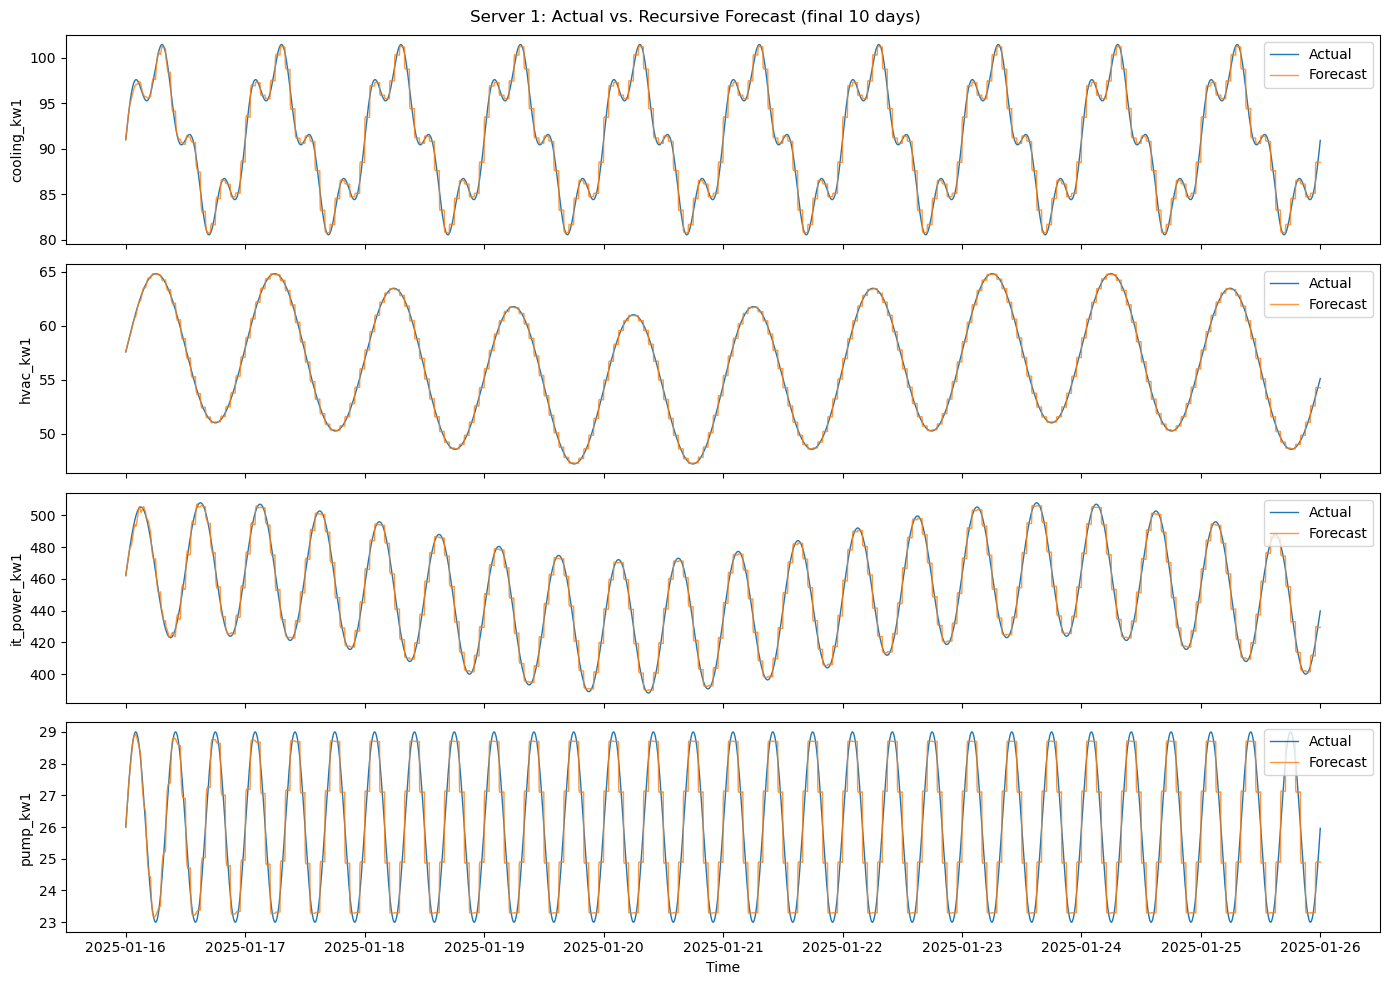

In [34]:
import matplotlib.pyplot as plt

server_to_plot = 1  # 1, 2, or 3

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, m in zip(axes, BASE_METRICS):
    col = f"{m}{server_to_plot}"
    ax.plot(actual_holdout.index, actual_holdout[col], label="Actual", linewidth=1)
    ax.plot(predictions_df.index, predictions_df[col], label="Forecast", linewidth=1, alpha=0.8)
    ax.set_ylabel(col)
    ax.legend(loc="upper right")

plt.suptitle(f"Server {server_to_plot}: Actual vs. Recursive Forecast (final 10 days)")
plt.xlabel("Time")
plt.tight_layout()
plt.show()


## 20. Download Outputs

In [35]:
IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False

if IN_COLAB:
    from google.colab import files as colab_files
    colab_files.download(txt_path)
    colab_files.download(csv_path)
else:
    print(f"Files are ready in the working directory: {txt_path}, {csv_path}")

Files are ready in the working directory: predictions.txt, predictions_with_timestamps.csv


## Summary & Notes

- **Model:** one XGBoost regressor per target (12 total), trained on the **delta from the previous
  minute** using lag/rolling/cyclical-time/seasonal-profile features with zero future leakage,
  validated against a naive persistence baseline, then retrained on all non-holdout data.
- **Recursive stability:** predictions are blended toward a fixed seasonal anchor as the forecast
  horizon grows (`SHRINK_HORIZON_MIN` / `ALPHA_MAX` in section 2), which prevents the unbounded
  drift that plain recursive lag-based forecasting is prone to over a 14,400-step horizon.
- **Honest evaluation:** section 12 backtests the exact recursive procedure on real, held-out
  validation data *before* you commit to the expensive final run.
- **Outputs:** `predictions.txt` (exact required format, no timestamps) and
  `predictions_with_timestamps.csv` (predictions + actuals, for your own plotting).

**If results still aren't good enough:**
- Try lowering `SHRINK_HORIZON_MIN` or raising `ALPHA_MAX` in section 2 if section 12's backtest
  still shows drift — this trades some short-term responsiveness for long-horizon stability.
- Try the opposite (raise `SHRINK_HORIZON_MIN`, lower `ALPHA_MAX`) if the backtest shows the forecast
  is *too* damped/flat compared to actual variability.
- If a specific target (e.g. one metric on one server) is consistently the worst performer, check
  whether that series behaves like a near-random-walk (very high, near-1.0 autocorrelation in its
  *own* first differences) — such series are fundamentally hard to forecast far into the future by
  any method, not just this one.
- Re-run the duplicate-server check in section 6 if any two servers' metrics look suspiciously close.
